In [1]:
try :
    from elasticsearch import Elasticsearch
    import os
    import sys
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from datetime import datetime
    from sklearn.naive_bayes import GaussianNB
    import numpy as np
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.svm import SVC
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import GradientBoostingClassifier
    import shap
    from sklearn.model_selection import GridSearchCV
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.metrics import accuracy_score,f1_score
    from sklearn.metrics import classification_report
    from sklearn.metrics import confusion_matrix
    from sklearn.feature_selection import SelectFromModel
    from sklearn.model_selection import train_test_split
    from catboost import Pool
    from catboost import CatBoostClassifier
except Exception as e :
    print("Some Modules are Missing{}".format(e))

# Read dataset

In [12]:
training_dataset= pd.read_csv("../datasets/training/final_training_dataset_no_history_SMOTENC.csv")
training_dataset["output_2"].value_counts()

NORMAL                     5080
brute_force                1250
XSS                        1250
Broken_Authentication      1250
WEB_SCAN                   1250
SENSITIVE_DATA_EXPOSURE    1250
SQL_INJECTION              1250
Name: output_2, dtype: int64

In [2]:
## read the data
dataset = pd.read_csv("../datasets/dataset.csv")
dataset["output_2"].value_counts()
dataset

Columns (10,40,41,42) have mixed types. Specify dtype option on import or set low_memory=False.


,_index,_type,_id,_score,_source.agent.ip,_source.agent.name,_source.agent.id,_source.manager.name,_source.data.protocol,_source.data.srcip,...,_source.rule.mitre.id,_source.rule.mitre.tactic,_source.rule.info,_source.decoder.parent,_source.data.srcip2,output_2,output_1,_source.agent.description,_source.rule.gpg13,_source.previous_log
0,wazuh-alerts-4.x-2022.07.19,_doc,3rE9FoIBL_7AcdV6DJfU,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,...,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN
1,wazuh-alerts-4.x-2022.07.19,_doc,4LE9FoIBL_7AcdV6DJfU,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,...,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN
2,wazuh-alerts-4.x-2022.07.19,_doc,4rE9FoIBL_7AcdV6DJfU,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,...,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN
3,wazuh-alerts-4.x-2022.07.19,_doc,47E9FoIBL_7AcdV6DJfU,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,...,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN
4,wazuh-alerts-4.x-2022.07.19,_doc,57E9FoIBL_7AcdV6DJfV,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,...,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46449,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,...,,,NaN,NaN,NaN,SQL_INJECTION,ATTACK,APACHE_SERVER,,
46450,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:192.168.200.46,...,,,NaN,NaN,NaN,NORMAL,NORMAL,APACHE_SERVER,,
46451,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,...,,,NaN,NaN,NaN,SQL_INJECTION,ATTACK,APACHE_SERVER,,
46452,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,...,,,NaN,NaN,NaN,SQL_INJECTION,ATTACK,APACHE_SERVER,,


In [8]:
pd.DataFrame(dataset["output_2"].value_counts().to_dict(),index=[1])

,SENSITIVE_DATA_EXPOSURE,SQL_INJECTION,NORMAL,WEB_SCAN,brute_force,XSS,Broken_Authentication
1,26558,6573,6350,5654,702,317,300


In [9]:
dataset["output_2"].value_counts()

SENSITIVE_DATA_EXPOSURE    26558
SQL_INJECTION               6573
NORMAL                      6350
WEB_SCAN                    5654
brute_force                  702
XSS                          317
Broken_Authentication        300
Name: output_2, dtype: int64

In [3]:
# all_features = ['_source.data.protocol',
#                          '_source.data.id',
#                          '_source.rule.firedtimes',
#                          '_source.rule.mail',
#                          '_source.rule.level',
#                          '_source.rule.description',
#                          '_source.rule.groups',
#                          '_source.rule.pci_dss',
#                          '_source.rule.tsc',
#                          '_source.rule.nist_800_53',
#                          '_source.rule.gdpr',
#                          '_source.rule.mitre.id',
#                          '_source.rule.frequency',
#                          '_source.rule.hipaa',
#                          '_source.agent.description',
#                          '_source.rule.id',        
#                         'output_1',
#                         'output_2' ]
# category_features= ['_source.data.protocol',
#                          '_source.data.id',
#                          '_source.rule.mail',
#                          '_source.rule.description',
#                          '_source.rule.groups',
#                          '_source.rule.pci_dss',
#                          '_source.rule.tsc',
#                          '_source.rule.nist_800_53',
#                          '_source.rule.gdpr',
#                          '_source.rule.mitre.id',
#                          '_source.rule.hipaa',
#                          '_source.agent.description',
#                         '_source.rule.id',
#                          '_source.rule.frequency']

# numerical_features = ['_source.rule.firedtimes',
#                       '_source.rule.level'
#                      ]



all_features = ['_source.data.protocol',
                         '_source.data.id',
                         '_source.rule.firedtimes',
                         '_source.rule.mail',
                         '_source.rule.level',
                         '_source.rule.description',
                         '_source.rule.groups',
                         '_source.rule.pci_dss',
                         '_source.rule.tsc',
                         '_source.rule.nist_800_53',
                         '_source.rule.gdpr',
                         '_source.rule.mitre.id',
                         '_source.rule.frequency',
                         '_source.rule.hipaa',
                         '_source.agent.description',
                        '_source.rule.id',
                        'output_1',
                        'output_2' ]
category_features= ['_source.data.protocol',
                         '_source.data.id',
                         '_source.rule.mail',
                         '_source.rule.description',
                         '_source.rule.groups',
                         '_source.rule.pci_dss',
                         '_source.rule.tsc',
                         '_source.rule.nist_800_53',
                         '_source.rule.gdpr',
                         '_source.rule.mitre.id',
                         '_source.rule.hipaa',
                         '_source.agent.description',
                        '_source.rule.id',

                         '_source.rule.frequency']

numerical_features = ['_source.rule.firedtimes',
                      '_source.rule.level'
                     ]

In [4]:
path_train="../datasets/training/final_training_dataset_no_history_SMOTENC.csv"
path_test= "../datasets/testing/final_testing_dataset_no_history.csv"
training = pd.read_csv(path_train)
training["_source.agent.description"].value_counts()

APACHE_SERVER    12580
Name: _source.agent.description, dtype: int64

In [5]:
def preprocessing(df):  

    #these category features if they didn't exist we will add them to the dataframe
    list_test_columns= list(df.columns)
    for i in range ( 0, len(category_features)):
        if(category_features[i] not in list_test_columns):
            df[category_features[i]] = " "
    for c in numerical_features:
        if(c not in list_test_columns):
            df[c] = 1
    # fill the columns that has None values with empty strings.
    for c in category_features:
        if(df[c].isnull().any()):
            df[c] = df[c].fillna(' ')
    # fill the columns rule level with rule.level = 3
    df["_source.rule.level"] = df["_source.rule.level"].fillna(1)
    df["_source.rule.firedtimes"] = df["_source.rule.firedtimes"].fillna(1)

    # fill mail values with 1 and 0 
    for index,row in df.iterrows():
        for cat_fe in category_features:
            if(isinstance(row[cat_fe],list)):
                df.at[index,cat_fe] = str(row[cat_fe])
        if (row["_source.rule.mail"]==True):
            df.at[index,"_source.rule.mail"] = 1
        else :
            df.at[index,"_source.rule.mail"] = 0
    df["_source.agent.description"] = "APACHE_SERVER"
    df = df.fillna(' ')
    return df

# Find the Importance For Each Feature 

## We Will use the most important Features to represent the Context For Each Record

In [13]:
def get_feature_importance_model_2():
    path_train="../datasets/training/final_training_dataset_no_history_SMOTENC.csv"
    path_test= "../datasets/testing/final_testing_dataset_no_history.csv"
    dataset_training = pd.read_csv(path_train)
    dataset_testing = pd.read_csv(path_test)
    dataset_training = preprocessing(dataset_training)
    dataset_testing = preprocessing(dataset_testing)
    
    # slice the training dataset and testing dataset to take the columns
    dataset_training = dataset_training[all_features]
    dataset_testing = dataset_testing[all_features]
    
    # take the features and leave the class
    y1_train = dataset_training["output_1"]
    X1_train = dataset_training.drop(['output_1','output_2'], axis=1)
    train_pool_1 =Pool(
        data=X1_train,
        label=y1_train,
        cat_features = category_features,
    )
    
    
    y1_validation = dataset_testing["output_1"]
    X1_validation = dataset_testing.drop(['output_1','output_2'], axis=1)
      
    test_pool_1 = Pool(
        data=X1_validation,
        label=y1_validation,
        cat_features=category_features,
    )
    
    dataset_training_attack = dataset_training[dataset_training["output_2"] != "NORMAL" ]
    y2_train= dataset_training_attack["output_2"]
    X2_train = dataset_training_attack.drop(['output_1','output_2'], axis=1)  
    train_pool_2 =Pool(
        data=X2_train,
        label=y2_train,
        cat_features = category_features,
    )

    dataset_testing_attack = dataset_testing[dataset_testing["output_2"] != "NORMAL" ]
    y2_validation= dataset_testing_attack["output_2"]
    X2_validation = dataset_testing_attack.drop(['output_1','output_2'], axis=1)  
    test_pool_2 = Pool(
        data=X2_validation,
        label=y2_validation,
        cat_features=category_features,
    )
    
    
    
    
    model_1 = CatBoostClassifier()

    model_2 = CatBoostClassifier()
    
    
#     model_1.load_model("../models/catboost_model_1.bin")
    model_2.load_model("../models/catboost_model_withContext_2.bin")
    imp_arr_2 = np.array(model_2.get_feature_importance(
    test_pool_2,
    "LossFunctionChange",
    prettified=True
    ))
    imp_arr_1 = np.array(model_1.get_feature_importance(
    test_pool_1,
    "LossFunctionChange",
    prettified=True
    ))
    print("Features with Importance")
#     print(imp_arr_1)
    shap.initjs()
    
    shap_values = model_2.get_feature_importance(
    data=test_pool_2, 
    type='ShapValues'
    )

    expected_values=shap_values[:,:,-1]
    expected_values = expected_values[0]
    _class=2
    shap.force_plot(expected_values[_class],shap_values[0,_class,:-1],feature_names=all_features[0:16])
    
    shap_values_1 = list()
    for i in range(0,len(shap_values)):
        predict= model_2.predict_proba([X2_validation.iloc[i,:]])
        result = np.where(predict[0] == np.amax(predict[0]))
        shap_values_1.append(shap_values[i][result[0][0]])
    
    shap_values_1 = np.array(shap_values_1)
    shap_values_1=shap_values_1[:,:-1]
    shap.summary_plot(shap_values_1,X2_validation)
    return imp_arr_1,imp_arr_2
    
    

In [14]:
imp_arr_1,imp_arr_2 = get_feature_importance_model_2()

CatBoostError: C:/Program Files (x86)/Go Agent/pipelines/BuildMaster/catboost.git/catboost/libs/data/model_dataset_compatibility.cpp:72: Feature history._source.rule.firedtimes is present in model but not in pool.

In [21]:
def get_feature_importance_model_1():
    path_train="../datasets/training/final_training_dataset_no_history_SMOTENC.csv"
    path_test= "../datasets/testing/final_testing_dataset_no_history.csv"
    dataset_training = pd.read_csv(path_train)
    dataset_testing = pd.read_csv(path_test)
    dataset_training = preprocessing(dataset_training)
    dataset_testing = preprocessing(dataset_testing)
    
    # slice the training dataset and testing dataset to take the columns
    dataset_training = dataset_training[all_features]
    dataset_testing = dataset_testing[all_features]
    
    # take the features and leave the class
    y1_train = dataset_training["output_1"]
    X1_train = dataset_training.drop(['output_1','output_2'], axis=1)
    train_pool_1 =Pool(
        data=X1_train,
        label=y1_train,
        cat_features = category_features,
    )
    
    
    y1_validation = dataset_testing["output_1"]
    X1_validation = dataset_testing.drop(['output_1','output_2'], axis=1)
      
    test_pool_1 = Pool(
        data=X1_validation,
        label=y1_validation,
        cat_features=category_features,
    )
    
    dataset_training_attack = dataset_training[dataset_training["output_2"] != "NORMAL" ]
    y2_train= dataset_training_attack["output_2"]
    X2_train = dataset_training_attack.drop(['output_1','output_2'], axis=1)  
    train_pool_2 =Pool(
        data=X2_train,
        label=y2_train,
        cat_features = category_features,
    )

    dataset_testing_attack = dataset_testing[dataset_testing["output_2"] != "NORMAL" ]
    y2_validation= dataset_testing_attack["output_2"]
    
    X2_validation = dataset_testing_attack.drop(['output_1','output_2'], axis=1)  
    test_pool_2 = Pool(
        data=X2_validation,
        label=y2_validation,
        cat_features=category_features,
    )
    
    
    
    
    model_1 = CatBoostClassifier()

    
    
    model_1.load_model("../models/catboost_model_1.bin")

    print("Features with Importance")
    shap.initjs()
    
    shap_values = model_1.get_feature_importance(
    data=test_pool_2, 
    type='ShapValues'
    )

    
    shap_values_1 = list()
    for i in range(0,len(shap_values)):
        predict= model_1.predict_proba([X1_validation.iloc[i,:]])
        result = np.where(predict[0] == np.amax(predict[0]))
        shap_values_1.append(shap_values[i][result[0][0]])
    
    shap_values_1 = np.array(shap_values_1)
    shap_values_1=shap_values_1[:]
    shap.summary_plot(shap_values_1,X1_validation)
    
    
    

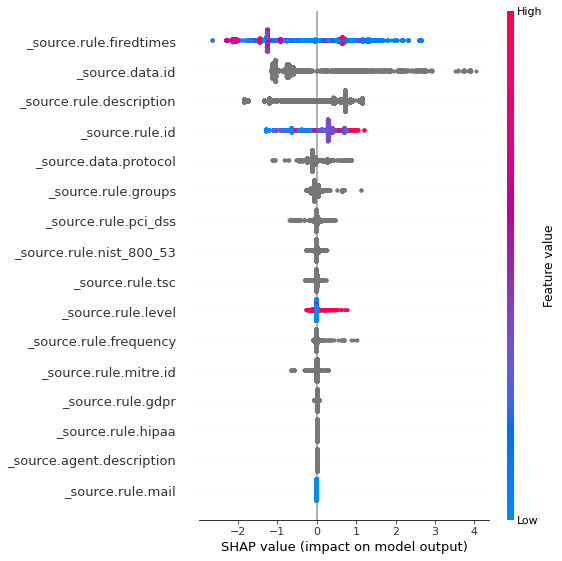

In [31]:
path_train="../datasets/training/final_training_dataset_no_history_SMOTENC.csv"
path_test= "../datasets/testing/final_testing_dataset_no_history.csv"
dataset_training = pd.read_csv(path_train)
dataset_testing = pd.read_csv(path_test)
dataset_training = preprocessing(dataset_training)
dataset_testing = preprocessing(dataset_testing)

dataset_training = dataset_training[all_features]
dataset_testing = dataset_testing[all_features]

# take the features and leave the class
y1_train = dataset_training["output_1"]
X1_train = dataset_training.drop(['output_1','output_2'], axis=1)
train_pool_1 =Pool(
    data=X1_train,
    label=y1_train,
    cat_features = category_features,
)


y1_validation = dataset_testing["output_1"]
X1_validation = dataset_testing.drop(['output_1','output_2'], axis=1)

test_pool_1 = Pool(
    data=X1_validation,
    label=y1_validation,
    cat_features=category_features,
)

model_1 = CatBoostClassifier()

model_1.load_model("../models/catboost_model_1.bin")
shap.initjs()
shap_values = model_1.get_feature_importance(
data=test_pool_1, 
type='ShapValues'
)
shap_values
shap.summary_plot(shap_values[:,:-1],X1_validation)


In [30]:
shap_values[:,-1]


array([-0.74165023, -0.74165023, -0.74165023, ..., -0.74165023,
       -0.74165023, -0.74165023])

In [27]:
imp_arr_1


array([['_source.agent.description', 0.11178139841803124],
       ['_source.rule.firedtimes', 0.06676453537077404],
       ['_source.data.id', 0.018512258650962482],
       ['_source.rule.level', 0.0008540454277114705],
       ['_source.data.protocol', 0.000762792413116943],
       ['_source.rule.frequency', 0.0004215993275181936],
       ['_source.rule.nist_800_53', 0.00026580242408580146],
       ['_source.rule.groups', 0.00023700827167247304],
       ['_source.rule.mail', 0.0],
       ['_source.rule.pci_dss', -1.2962038557356949e-05],
       ['_source.rule.hipaa', -2.4578538439609665e-05],
       ['_source.rule.tsc', -0.0003731304949818083],
       ['_source.rule.mitre.id', -0.000493832537596608],
       ['_source.rule.description', -0.0012367868822487037],
       ['_source.rule.id', -0.0018319577232089601],
       ['_source.rule.gdpr', -0.0019005958015723828]], dtype=object)

In [28]:
imp_arr_2

array([['_source.agent.description', 0.452991511986212],
       ['_source.rule.description', 0.04490089284958468],
       ['_source.data.protocol', 0.01848839514793746],
       ['_source.rule.firedtimes', 0.007974563109909627],
       ['_source.rule.groups', 0.0033771049777510664],
       ['_source.rule.gdpr', 0.001832935471894337],
       ['_source.rule.pci_dss', 0.001392948651504966],
       ['_source.rule.tsc', 0.00044098149446794577],
       ['_source.rule.mail', 0.0],
       ['_source.rule.nist_800_53', 0.0],
       ['_source.rule.hipaa', 0.0],
       ['_source.rule.frequency', -0.0002807902793954542],
       ['_source.rule.mitre.id', -0.0005338324555165808],
       ['_source.rule.level', -0.00964680554183775],
       ['_source.rule.id', -0.0097707128075874],
       ['_source.data.id', -0.015820200459782136]], dtype=object)

In [95]:
dataset["output_2"].value_counts()

NORMAL                     6350
brute_force                1250
XSS                        1250
Broken_Authentication      1250
WEB_SCAN                   1250
SENSITIVE_DATA_EXPOSURE    1250
SQL_INJECTION              1250
Name: output_2, dtype: int64

In [65]:
indices = np.where(imp_arr_1[:,1] > 0)
importance_sum_1 = 0
for i in indices[0]:
    importance_sum_1 = importance_sum_1 + imp_arr_1[i,1]
    
print(importance_sum_1)

0.1865090777511305


In [66]:
cum_imp_sum = 0
History_features=[]
for i in indices[0]:
    temp = imp_arr_1[i,1]
    cum_imp_sum += temp 
    History_features.append(imp_arr_1[i,0])
    if(cum_imp_sum/importance_sum_1 *100 > 95):
        break
print(cum_imp_sum/importance_sum_1 *100)
print(History_features)

95.44621524554441
['_source.data.id', '_source.rule.firedtimes']


In [67]:
indices_2 = np.where(imp_arr_2[:,1] > 0)
importance_sum_2 = 0
for i in indices[0]:
    importance_sum_2 = importance_sum_2 + imp_arr_2[i,1]
    
print(importance_sum_2)

0.20598701063822517


In [68]:
cum_imp_sum = 0
History_features_2=[]
for i in indices[0]:
    temp = imp_arr_2[i,1]
    cum_imp_sum += temp 
    History_features_2.append(imp_arr_2[i,0])
    if(cum_imp_sum/importance_sum_2 *100 > 95):
        break
print(cum_imp_sum/importance_sum_2 *100)
print(History_features_2)

97.6671285469233
['_source.rule.firedtimes', '_source.rule.mitre.id']


## NOW it is the time to add the history features to the dataset 

In [33]:
pd.set_option("display.max_rows",100)
pd.set_option("display.max_columns",100)

## Finding All the mitre technique id in the Dataset 

In [34]:
dataset = pd.read_csv("../datasets/dataset.csv")
aa = dataset['_source.rule.mitre.id'].value_counts()
ss = set()
for item in aa.index:
    if (item == " "):
        continue
    temp= item.replace('"','')
    temp = temp.replace("[",'')
    temp = temp.replace("]",'')
    ls = temp.split(',')
    for rule in ls :
        if(rule == " " ):
            continue
        ss.add(rule)

print(ss)



{'T1210', 'T1190', 'T1068', 'T1212', 'T1055', 'T1083', 'T1064'}


Columns (10,40,41,42) have mixed types. Specify dtype option on import or set low_memory=False.


## change the type of data id to int

In [35]:
for index,row in dataset.iterrows():
    if(row["_source.data.id"] == " " ):
        dataset.at[index,"_source.data.id"] = 0
    else :
        dataset.at[index,"_source.data.id"] = int(row["_source.data.id"])

print(type(dataset["_source.data.id"][0]))


<class 'int'>


In [36]:
## Initialize History Columns to the Dataset

dataset["history._source.rule.firedtimes"] = 1
dataset["history._source.data.id.200"]= 0
dataset["history._source.data.id.300"]= 0
dataset["history._source.data.id.400"]= 0
dataset["history._source.data.id.500"]= 0
ss = list (ss)
for item in ss:
    dataset[item] = 0


In [37]:
dataset

,_index,_type,_id,_score,_source.agent.ip,_source.agent.name,_source.agent.id,_source.manager.name,_source.data.protocol,_source.data.srcip,_source.data.id,_source.data.url,_source.rule.firedtimes,_source.rule.mail,_source.rule.level,_source.rule.description,_source.rule.groups,_source.rule.id,_source.decoder.name,_source.full_log,_source.input.type,_source.@timestamp,_source.location,_source.id,_source.timestamp,_source.rule.pci_dss,_source.rule.hipaa,_source.rule.tsc,_source.rule.nist_800_53,_source.rule.frequency,_source.rule.gdpr,_source.previous_output,_source.rule.mitre.technique,_source.rule.mitre.id,_source.rule.mitre.tactic,_source.rule.info,_source.decoder.parent,_source.data.srcip2,output_2,output_1,_source.agent.description,_source.rule.gpg13,_source.previous_log,history._source.rule.firedtimes,history._source.data.id.200,history._source.data.id.300,history._source.data.id.400,history._source.data.id.500,T1210,T1190,T1068,T1212,T1055,T1083,T1064
0,wazuh-alerts-4.x-2022.07.19,_doc,3rE9FoIBL_7AcdV6DJfU,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,200,/rest/admin/application-configuration,351,False,1,Ignored URLs (simple queries).,"[""web"",""accesslog""]",31108,web-accesslog,10.10.30.158 - - [19/Jul/2022:11:34:33 +0000] ...,log,7/19/2022 11:34,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1658230474,7/19/2022 11:34,,,,,,,,,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0
1,wazuh-alerts-4.x-2022.07.19,_doc,4LE9FoIBL_7AcdV6DJfU,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,200,/api/Challenges/?name=Score%20Board,43,False,1,Access log messages grouped.,"[""web"",""accesslog""]",31100,web-accesslog,10.10.30.158 - - [19/Jul/2022:11:34:33 +0000] ...,log,7/19/2022 11:34,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1658230474,7/19/2022 11:34,,,,,,,,,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0
2,wazuh-alerts-4.x-2022.07.19,_doc,4rE9FoIBL_7AcdV6DJfU,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,200,/rest/products/search?q=,44,False,1,Access log messages grouped.,"[""web"",""accesslog""]",31100,web-accesslog,10.10.30.158 - - [19/Jul/2022:11:34:33 +0000] ...,log,7/19/2022 11:34,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1658230474,7/19/2022 11:34,,,,,,,,,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0
3,wazuh-alerts-4.x-2022.07.19,_doc,47E9FoIBL_7AcdV6DJfU,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,200,/api/Quantitys/,354,False,1,Ignored URLs (simple queries).,"[""web"",""accesslog""]",31108,web-accesslog,10.10.30.158 - - [19/Jul/2022:11:34:33 +0000] ...,log,7/19/2022 11:34,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1658230474,7/19/2022 11:34,,,,,,,,,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0
4,wazuh-alerts-4.x-2022.07.19,_doc,57E9FoIBL_7AcdV6DJfV,2.785566,10.10.50.7,ubuntu,12,ubuntu-linux,GET,10.10.30.158,304,/api/Challenges/?name=Score%20Board,45,False,1,Access log messages grouped.,"[""web"",""accesslog""]",31100,web-accesslog,10.10.30.158 - - [19/Jul/2022:11:34:34 +0000] ...,log,7/19/2022 11:34,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1658230474,7/19/2022 11:34,,,,,,,,,,,,NaN,NaN,NORMAL,NORMAL,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46449,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,500,/rest/user/login,1,False,5,Web server 500 error code (Internal Error).,"[""web"",""accesslog"",""system_error""]",31122,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:10:00:40 +00...,log,6/21/2022 10:00,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655805641,6/21/2022 10:00,,,,,,,,,,,NaN,NaN,NaN,SQL_INJECTION,ATTACK,APACHE_SERVER,,,1,0,0,0,0,0,0,0,0,0,0,0
46450,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:192.168.200.4

## Small amount of records has undefined Src_IP

In [38]:
dataset["_source.data.srcip"].value_counts()
available_Ips = ["10.10.30.158","::ffff:10.10.30.136","::ffff:10.10.30.45","10.10.30.136","::ffff:10.10.30.106","::ffff:10.10.30.157","::ffff:10.0.0.10","::ffff:10.10.30.183","10.10.30.183","::ffff:10.10.30.158","10.10.30.45"]
indices = [] 
for index,row in dataset.iterrows():
    if(row["_source.data.srcip"] not in available_Ips):
        indices.append(index)
dataset = dataset.drop(indices,axis=0)
dataset["_source.data.srcip"].value_counts()

10.10.30.158           27883
10.10.30.136            6517
::ffff:10.10.30.136     5663
::ffff:10.10.30.45      2897
::ffff:10.10.30.157     1595
::ffff:10.10.30.106     1394
::ffff:10.0.0.10         114
::ffff:10.10.30.183       86
10.10.30.183               5
::ffff:10.10.30.158        2
10.10.30.45                1
Name: _source.data.srcip, dtype: int64

In [39]:
test = dataset
test["_source.@timestamp"]

0        7/19/2022 11:34
1        7/19/2022 11:34
2        7/19/2022 11:34
3        7/19/2022 11:34
4        7/19/2022 11:34
              ...       
46448     6/21/2022 9:53
46449    6/21/2022 10:00
46451    6/21/2022 10:04
46452    6/21/2022 10:04
46453    6/21/2022 10:04
Name: _source.@timestamp, Length: 46157, dtype: object

## sort the Actions According to the time

In [40]:
test_1 = pd.to_datetime(test["_source.@timestamp"],format="%m/%d/%Y %H:%M")
test["timestamp"] = test_1
final_test =test.sort_values("timestamp")
pd.set_option("display.max_rows",100)
final_test

,_index,_type,_id,_score,_source.agent.ip,_source.agent.name,_source.agent.id,_source.manager.name,_source.data.protocol,_source.data.srcip,_source.data.id,_source.data.url,_source.rule.firedtimes,_source.rule.mail,_source.rule.level,_source.rule.description,_source.rule.groups,_source.rule.id,_source.decoder.name,_source.full_log,_source.input.type,_source.@timestamp,_source.location,_source.id,_source.timestamp,_source.rule.pci_dss,_source.rule.hipaa,_source.rule.tsc,_source.rule.nist_800_53,_source.rule.frequency,_source.rule.gdpr,_source.previous_output,_source.rule.mitre.technique,_source.rule.mitre.id,_source.rule.mitre.tactic,_source.rule.info,_source.decoder.parent,_source.data.srcip2,output_2,output_1,_source.agent.description,_source.rule.gpg13,_source.previous_log,history._source.rule.firedtimes,history._source.data.id.200,history._source.data.id.300,history._source.data.id.400,history._source.data.id.500,T1210,T1190,T1068,T1212,T1055,T1083,T1064,timestamp
46400,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,401,/rest/user/login,5,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:45:48 +00...,log,6/21/2022 7:45,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655797548,6/21/2022 7:45,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,1,0,0,0,0,0,0,0,0,0,0,0,2022-06-21 07:45:00
46360,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,401,/rest/user/login,6,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:53:02 +00...,log,6/21/2022 7:53,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655797983,6/21/2022 7:53,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,1,0,0,0,0,0,0,0,0,0,0,0,2022-06-21 07:53:00
46442,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,400,/api/Users/,7,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:54:47 +00...,log,6/21/2022 7:54,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655798089,6/21/2022 7:54,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,1,0,0,0,0,0,0,0,0,0,0,0,2022-06-21 07:54:00
46389,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,401,/rest/user/login,12,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:57:23 +00...,log,6/21/2022 7:57,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655798245,6/21/2022 7:57,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,1,0,0,0,0,0,0,0,0,0,0,0,2022-06-21 07:57:00
46333,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,401,/rest/user/login,9,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:57:22 +00...,log,6/21/2022 7:57,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655798243,6/21/2022 7:57,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,1,0,0,0,0,0,0,0,0,0,0,0,2022-06-21 07:57:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33526,waz

In [41]:
final_test_1 = final_test.reset_index()
final_test_1 = final_test_1.drop("index",axis=1)
final_test = final_test_1

# We will find the frequency of the mitre id attacks in the context to each record

# we will take max rule firedtimes from the context

# we will take the number of records fall into 20* , 30* , 40*, 50* data id

In [42]:
final_test["count_events"] = 0
for index,row in final_test.iterrows():
    src_ip = row["_source.data.srcip"]
    max_firedtimes = 1
    num = 0
    for i in range (max(index-1,0) , -1, -1):
        if(num ==35 ):break
        if(final_test.at[i,"_source.data.srcip"] ==src_ip ):
            num+=1
            max_firedtimes = max(max_firedtimes,final_test.at[i,"_source.rule.firedtimes"])
            temp = final_test.at[i,"_source.rule.mitre.id"]
            for item in ss:
                if(item in temp):
                    final_test.at[index,item] = final_test.at[index,item] + 1
            temp = final_test.at[i,'_source.data.id']//10
            if (temp == 20):
                final_test.at[index,'history._source.data.id.200'] += 1
            elif (temp == 30):
                final_test.at[index,'history._source.data.id.300'] += 1
            elif (temp == 40):
                final_test.at[index,'history._source.data.id.400'] += 1
            elif (temp == 50):
                final_test.at[index,'history._source.data.id.500'] += 1

    
    # average of rule firedtimes
    final_test.at[index,"history._source.rule.firedtimes"] = max_firedtimes
    
    # the number of history events
    final_test.at[index,"count_events"] = num
final_test

,_index,_type,_id,_score,_source.agent.ip,_source.agent.name,_source.agent.id,_source.manager.name,_source.data.protocol,_source.data.srcip,_source.data.id,_source.data.url,_source.rule.firedtimes,_source.rule.mail,_source.rule.level,_source.rule.description,_source.rule.groups,_source.rule.id,_source.decoder.name,_source.full_log,_source.input.type,_source.@timestamp,_source.location,_source.id,_source.timestamp,_source.rule.pci_dss,_source.rule.hipaa,_source.rule.tsc,_source.rule.nist_800_53,_source.rule.frequency,_source.rule.gdpr,_source.previous_output,_source.rule.mitre.technique,_source.rule.mitre.id,_source.rule.mitre.tactic,_source.rule.info,_source.decoder.parent,_source.data.srcip2,output_2,output_1,_source.agent.description,_source.rule.gpg13,_source.previous_log,history._source.rule.firedtimes,history._source.data.id.200,history._source.data.id.300,history._source.data.id.400,history._source.data.id.500,T1210,T1190,T1068,T1212,T1055,T1083,T1064,timestamp,count_events
0,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,401,/rest/user/login,5,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:45:48 +00...,log,6/21/2022 7:45,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655797548,6/21/2022 7:45,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,5,0,0,1,0,0,0,0,0,0,0,0,2022-06-21 07:45:00,1
1,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,401,/rest/user/login,6,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:53:02 +00...,log,6/21/2022 7:53,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655797983,6/21/2022 7:53,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,5,0,0,1,0,0,0,0,0,0,0,0,2022-06-21 07:53:00,1
2,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,400,/api/Users/,7,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:54:47 +00...,log,6/21/2022 7:54,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655798089,6/21/2022 7:54,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,6,0,0,2,0,0,0,0,0,0,0,0,2022-06-21 07:54:00,2
3,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,401,/rest/user/login,12,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:57:23 +00...,log,6/21/2022 7:57,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655798245,6/21/2022 7:57,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,7,0,0,3,0,0,0,0,0,0,0,0,2022-06-21 07:57:00,3
4,NaN,NaN,NaN,NaN,192.168.200.135,ubuntu,3,wazuh-manager,POST,::ffff:10.0.0.10,401,/rest/user/login,9,False,5,Web server 400 error code.,"[""web"",""accesslog"",""attack""]",31101,web-accesslog,::ffff:10.0.0.10 - - [21/Jun/2022:07:57:22 +00...,log,6/21/2022 7:57,/home/sss/juice-shop_14.0.1/logs/access.log.20...,1655798243,6/21/2022 7:57,"[""6.5"",""11.4""]",,"[""CC6.6"",""CC7.1"",""CC8.1"",""CC6.1"",""CC6.8"",""CC7....","[""SA.11"",""SI.4""]",,"[""IV_35.7.d""]",,,,,NaN,NaN,NaN,XSS,ATTACK,APACHE_SERVER,,,12,0,0,4,0,0,0,0,0,0,0,0,2022-06-21 07:57:00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4

In [43]:
final_test[['history._source.rule.firedtimes', 'history._source.data.id.200',
       'history._source.data.id.300', 'history._source.data.id.400',
       'history._source.data.id.500', 'T1212', 'T1068', 'T1064', 'T1210',
       'T1083', 'T1055', 'T1190', 'timestamp', 'count_events']]            
final_test['T1210'].value_counts()

0    45912
1      245
Name: T1210, dtype: int64

In [44]:
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)


In [45]:
check=final_test.head(100)

In [46]:
check[["_source.data.srcip","_source.rule.mitre.id",'T1212', 'T1068', 'T1064', 'T1210',
       'T1083', 'T1055', 'T1190','count_events']]

,_source.data.srcip,_source.rule.mitre.id,T1212,T1068,T1064,T1210,T1083,T1055,T1190,count_events
0,::ffff:10.0.0.10,,0,0,0,0,0,0,0,1
1,::ffff:10.0.0.10,,0,0,0,0,0,0,0,1
2,::ffff:10.0.0.10,,0,0,0,0,0,0,0,2
3,::ffff:10.0.0.10,,0,0,0,0,0,0,0,3
4,::ffff:10.0.0.10,,0,0,0,0,0,0,0,4
5,::ffff:10.0.0.10,,0,0,0,0,0,0,0,5
6,::ffff:10.0.0.10,,0,0,0,0,0,0,0,6
7,::ffff:10.0.0.10,,0,0,0,0,0,0,0,7
8,::ffff:10.0.0.10,,0,0,0,0,0,0,0,8
9,::ffff:10.0.0.10,,0,0,0,0,0,0,0,9


In [47]:
final_test.columns

Index(['_index', '_type', '_id', '_score', '_source.agent.ip',
       '_source.agent.name', '_source.agent.id', '_source.manager.name',
       '_source.data.protocol', '_source.data.srcip', '_source.data.id',
       '_source.data.url', '_source.rule.firedtimes', '_source.rule.mail',
       '_source.rule.level', '_source.rule.description', '_source.rule.groups',
       '_source.rule.id', '_source.decoder.name', '_source.full_log',
       '_source.input.type', '_source.@timestamp', '_source.location',
       '_source.id', '_source.timestamp', '_source.rule.pci_dss',
       '_source.rule.hipaa', '_source.rule.tsc', '_source.rule.nist_800_53',
       '_source.rule.frequency', '_source.rule.gdpr',
       '_source.previous_output', '_source.rule.mitre.technique',
       '_source.rule.mitre.id', '_source.rule.mitre.tactic',
       '_source.rule.info', '_source.decoder.parent', '_source.data.srcip2',
       'output_2', 'output_1', '_source.agent.description',
       '_source.rule.gpg13', '_sou

In [336]:
final_test.to_csv("../datasets/test_dataset_with_history_35.csv",index=False)